In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def webcam_masking_cv2():
    cap = cv2.VideoCapture(0)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    while cap.isOpened():
        ## Capture frame-by-frame
        ret, frame = cap.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            face = frame[y:y+h, x:x+w]
            mask = np.zeros_like(face)
            mask_height, mask_width = mask.shape[:2]
            cv2.ellipse(mask, (mask_width//2, mask_height//2 + mask_height//8), 
                        (mask_width//2, mask_height//2), 0, 0, 360, (255, 255, 255), -1)
            pixelated_blur = cv2.resize(face, (mask_width//20, mask_height//20), interpolation=cv2.INTER_NEAREST)
            pixelated_blur = cv2.resize(pixelated_blur, (mask_width, mask_height), interpolation=cv2.INTER_NEAREST)
            frame[y:y+h, x:x+w] = np.where(mask == 255, pixelated_blur, face)

        cv2.imshow('frame', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [3]:
webcam_masking_cv2()

(195, 150, 3)


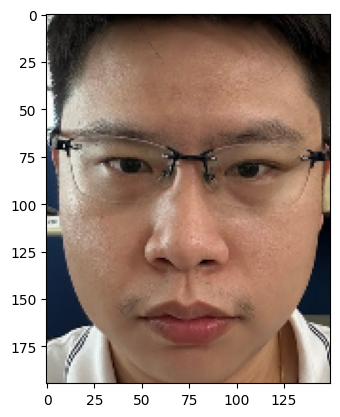

In [4]:
template = cv2.imread('images/face_image.jpg')
template.shape

template_resized = cv2.resize(template, (150, int(150/template.shape[1]*template.shape[0])))
print(template_resized.shape)

tpl = template_resized.copy()
plt.imshow(cv2.cvtColor(tpl, cv2.COLOR_BGR2RGB))


In [21]:


def multiscale_match(frame, template, scales=np.linspace(1.5,1.8,25)):
    th, tw = template.shape[:2]
    best = {'val': -1, 'loc': None, 'scale': None, 'w':None, 'h':None}
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    tpl_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

    for s in scales:
        nw, nh = int(tw * s), int(th * s)
        if nw < 8 or nh < 8 or nw > frame.shape[1] or nh > frame.shape[0]:
            continue
        tpl_resized = cv2.resize(tpl_gray, (nw, nh), interpolation=cv2.INTER_AREA)
        res = cv2.matchTemplate(gray, tpl_resized, cv2.TM_CCOEFF_NORMED)
        _, maxVal, _, maxLoc = cv2.minMaxLoc(res)
        if maxVal > best['val']:
            best.update({'val': maxVal, 'loc': maxLoc, 'scale': s, 'w': nw, 'h': nh})

    if best['loc'] is None:
        return None
    x, y = best['loc']
    return (x, y, best['w'], best['h'], best['val'])

def webcam_masking_template():

    cap = cv2.VideoCapture(0)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')     
    fps = 4                                     
    ret, frame = cap.read()
    height, width = frame.shape[:2]
    out = cv2.VideoWriter('output.mp4', fourcc, fps, (width, height))

    while cap.isOpened():

        ret, frame = cap.read()
    
        if not ret:
            break

        res = multiscale_match(frame, tpl, scales=np.linspace(1.2,1.5,25))
        x, y, w, h, score = res
        x, y, w, h = int(x), int(y), int(w), int(h)
        # cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        face = frame[y:y+h, x:x+w]
        mask = np.zeros_like(face)
        mask_height, mask_width = mask.shape[:2]
        mask = cv2.ellipse(
            mask, 
            (mask_width//2, mask_height//2 + mask_height//8), 
            (mask_width//2, mask_height//2), 0, 0, 360, (255, 255, 255), -1
        )
        pixelated_blur = cv2.resize(face, (mask_width//10, mask_height//20), interpolation=cv2.INTER_NEAREST)
        pixelated_blur = cv2.resize(pixelated_blur, (mask_width, mask_height), interpolation=cv2.INTER_NEAREST)
        frame[y:y+h, x:x+w] = np.where(mask == 255, pixelated_blur, face)

        out.write(frame)  
        cv2.imshow('frame', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    out.release()
    cv2.destroyAllWindows()

In [22]:
webcam_masking_template()